In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']


/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [9]:
# functions
def data_processing(path = '../../sample_table/ewma_6h_scaling.csv'):
    data = pd.read_csv(path)    
    data = data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd','humid', 'temp', 'precip_form', 'precip', 'isHoliday']]
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data['MOY'] = data['REG_DTIME'].dt.month
    data["time_idx"] =  \
    data["REG_DTIME"].dt.year * 365*24 + \
    data["REG_DTIME"].dt.day_of_year * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['MOY'] = data['MOY'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)
    #data['count'] = data['count'].round(5)

    return data

def get_training(data , max_prediction_length, max_encoder_length):
    # traing data 생성
    max_prediction_length = max_prediction_length
    max_encoder_length = max_encoder_length
    training_cutoff = data["time_idx"].max() - max_prediction_length

    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=24,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=[],
        time_varying_known_reals=[],
        #variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
        time_varying_unknown_categoricals=[],
        time_varying_unknown_reals=['count'], 
        target_normalizer=GroupNormalizer(
            groups=["h_dong"], 
            transformation="relu",
            center = False
        ),
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True,
        #predict_mode = False
        )
    return training

def get_val_dataloader(training , data , time_idx):
    batch_size= 32    
    test_data = data[data['time_idx'] < time_idx]
    validation = TimeSeriesDataSet.from_dataset(training, test_data, predict=True, stop_randomization=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=1)
    return val_dataloader

def countious_prediction(training, tft ,data, dong, title):
    plt.figure(figsize=(16,4))
    predition3 , predition4, predition5, predition6 = np.array([]) , np.array([]) , np.array([]) , np.array([])
    for i in range(1,59):
        val_data = get_val_dataloader(training ,data, 8760+24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        #print(idx_df['time_idx'].loc[0])
        dong_idx = idx_df[idx_df['h_dong'] == dong].index[0]
        predition3 = np.concatenate([predition3,pred['prediction'][dong_idx, : , 3]])
        predition4 = np.concatenate([predition4,pred['prediction'][dong_idx, : , 4]])
        predition5 = np.concatenate([predition5,pred['prediction'][dong_idx, : , 5]])
        predition6 = np.concatenate([predition6,pred['prediction'][dong_idx, : , 6]])
    
    dong_df = data[data['h_dong']==dong]
    df_index = dong_df[dong_df['time_idx'] > 8760-1]['REG_DTIME']
    org_count = dong_df[dong_df['time_idx'] > 8760-1]['count']
    
    x = np.arange(len(predition6))
    plt.plot(df_index,org_count , label = 'orginal')
    plt.plot(df_index,predition3 ,label = '50% prediction', alpha= 0.6, linestyle='--')
    plt.plot(df_index,predition4 ,label = '70% prediction', alpha= 0.6, linestyle='--')
    plt.plot(df_index,predition5 ,label = '90% prediction', alpha= 0.6, linestyle='--')
    plt.plot(df_index,predition6 ,label = '98% prediction', alpha= 0.6, linestyle='--')
    plt.title(f'{dong} {title}')
    plt.legend()
    

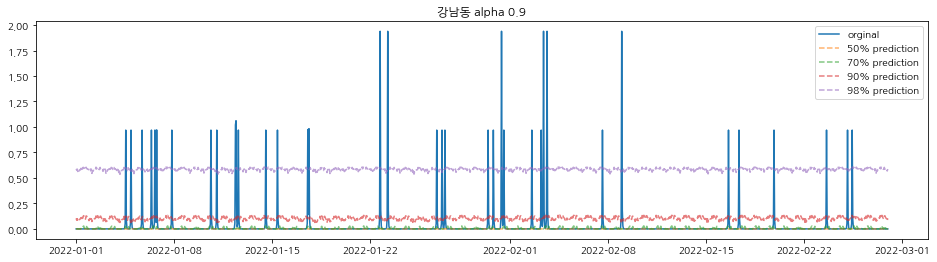

In [7]:
# alpha
data = data_processing('../TEST_ewma/ewma_alpha_09.csv')
train_data = data[data['time_idx']  < 8760]
training = get_training(train_data,24, 24*7)
model_path = 'etc/lightning_logs/version_0/checkpoints/epoch=199-step=1000.ckpt'

tft = TemporalFusionTransformer.load_from_checkpoint(model_path)
countious_prediction(training, tft, data, '강남동' , 'alpha 0.9')

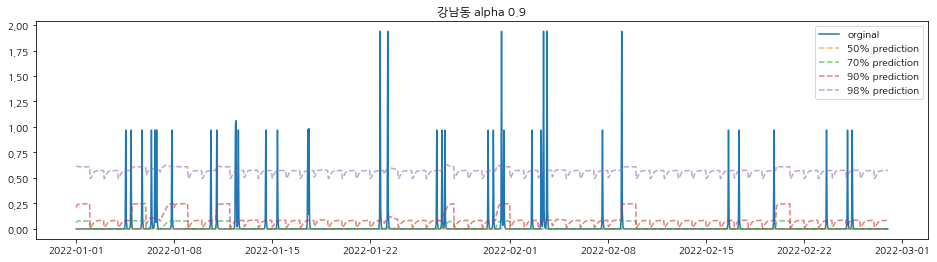

In [10]:
# alpha
data = data_processing('../TEST_ewma/ewma_alpha_09.csv')
train_data = data[data['time_idx']  < 8760]
training = get_training(train_data,24, 24*7)
model_path = 'etc/lightning_logs/version_3/checkpoints/epoch=49-step=250.ckpt'


tft = TemporalFusionTransformer.load_from_checkpoint(model_path)
countious_prediction(training, tft, data, '강남동' , 'alpha 0.9')